# Common Assignment Mistakes — Tiny, Focused Demos in PyTorch

This notebook is intentionally **small and explicit**.  
It does **not** try to build a strong classifier. Its only goal is to show the **core idea behind each mistake** and a **minimal fix**.

## What this notebook covers

This notebook follows your requested structure and focuses only on these mistakes:

1. **Reporting only overall accuracy instead of per-class metrics**
2. **Feature maps: how to extract them and visualize them correctly**
3. **Bad path handling: multiple roots, absolute paths, scattered outputs**
5. **Saving scores but not verifying them after reloading the model**
6. **Saving the last model instead of the best validation model**
9. **Using `shuffle=True` for validation / test when saving ordered scores**
10. **Not showing a clean 3-run experiment setup**
11. **Forgetting `model.eval()` and `torch.no_grad()` during validation / test**
12. **Feature map visualizations not saved in a fixed, reproducible way**

## Style of the demos

- Very small models: **2–3 layers only**
- Synthetic data where that is enough
- CIFAR-10 only where images are actually useful
- Detailed English explanations
- Minimal code, but still fully runnable

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image

from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

# -----------------------------
# Global configuration
# -----------------------------
SEED = 42
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / ".." / "Datasets"
ARTIFACTS_DIR = PROJECT_ROOT / "demo_artifacts"
RUNS_DIR = ARTIFACTS_DIR / "runs"
SPLITS_DIR = ARTIFACTS_DIR / "splits"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FEATURE_MAP_DIR = ARTIFACTS_DIR / "feature_maps"

for folder in [ARTIFACTS_DIR, RUNS_DIR, SPLITS_DIR, FIGURES_DIR, FEATURE_MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

print("Device:", DEVICE)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

Device: cpu
PROJECT_ROOT: c:\Users\jom_j\Documents\Master\Courses\IN4310\Coursework\Week_06
DATASET_ROOT: c:\Users\jom_j\Documents\Master\Courses\IN4310\Coursework\Week_06\..\Datasets
ARTIFACTS_DIR: c:\Users\jom_j\Documents\Master\Courses\IN4310\Coursework\Week_06\demo_artifacts


## A tiny CIFAR-10 helper

We only need CIFAR-10 for the image-related mistakes.  
The notebook uses **`ToTensor()` only**, because the point here is visualization and file handling, not heavy training.

In [2]:
cifar_transform = transforms.ToTensor()
cifar_test = torchvision.datasets.CIFAR10(
    root=DATASET_ROOT,
    train=False,
    download=True,
    transform=cifar_transform
)
CIFAR_CLASSES = cifar_test.classes
print("CIFAR-10 classes:", CIFAR_CLASSES)
print("Number of test images:", len(cifar_test))

Files already downloaded and verified
CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of test images: 10000


# Error 1 — Reporting only overall accuracy instead of per-class metrics

## The mistake

A student reports only one number such as:

- `overall accuracy = 0.84`

and stops there.

That is a problem because this single number can hide the fact that the model:
- is very good on frequent classes,
- but weak on rare classes.

In other words, **overall accuracy** and **mean class accuracy** are **not the same thing**.

## The fix

For classification tasks, report at least:

- **overall accuracy**
- **per-class accuracy**
- **mean class accuracy**
- **per-class AP**
- **mAP**

Below we use a tiny **two-layer MLP** on a small **mock imbalanced dataset**.
The point is not model quality.  
The point is to show **how to compute the right metrics**.

In [3]:
def make_mock_dataset(n_per_class=(240, 70, 20), feature_dim=8, seed=SEED):
    g = torch.Generator().manual_seed(seed)

    # Make class 0 easy and frequent, class 2 rare and harder.
    x0 = torch.randn(n_per_class[0], feature_dim, generator=g) * 0.8 + 0.0
    x1 = torch.randn(n_per_class[1], feature_dim, generator=g) * 0.9 + 1.5
    x2 = torch.randn(n_per_class[2], feature_dim, generator=g) * 1.2 + 1.2  # overlaps more with class 1

    y0 = torch.zeros(n_per_class[0], dtype=torch.long)
    y1 = torch.ones(n_per_class[1], dtype=torch.long)
    y2 = torch.full((n_per_class[2],), 2, dtype=torch.long)

    X = torch.cat([x0, x1, x2], dim=0)
    y = torch.cat([y0, y1, y2], dim=0)
    return X, y

X, y = make_mock_dataset()
X_train, X_val, y_train, y_val = train_test_split(
    X.numpy(), y.numpy(),
    test_size=0.35,
    random_state=SEED,
    stratify=y.numpy()
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

train_loader_1 = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader_1 = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

class TinyMLP(nn.Module):
    def __init__(self, in_dim=8, hidden_dim=16, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model_1 = TinyMLP().to(DEVICE)
criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = optim.Adam(model_1.parameters(), lr=1e-2)

for epoch in range(25):
    model_1.train()
    for xb, yb in train_loader_1:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_1.zero_grad()
        logits = model_1(xb)
        loss = criterion_1(logits, yb)
        loss.backward()
        optimizer_1.step()

def evaluate_per_class_metrics(model, loader, num_classes=3):
    model.eval()

    all_targets = []
    all_preds = []
    all_probs = []

    class_correct = np.zeros(num_classes, dtype=np.int64)
    class_total = np.zeros(num_classes, dtype=np.int64)

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_np = yb.cpu().numpy()
            p_np = preds.cpu().numpy()
            pr_np = probs.cpu().numpy()

            for c in range(num_classes):
                mask = y_np == c
                class_total[c] += mask.sum()
                class_correct[c] += (p_np[mask] == c).sum()

            all_targets.append(y_np)
            all_preds.append(p_np)
            all_probs.append(pr_np)

    targets = np.concatenate(all_targets)
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    per_class_acc = np.divide(
        class_correct,
        class_total,
        out=np.zeros_like(class_correct, dtype=np.float64),
        where=class_total > 0,
    )

    per_class_ap = []
    for c in range(num_classes):
        y_true = (targets == c).astype(np.int32)
        y_score = probs[:, c]
        per_class_ap.append(average_precision_score(y_true, y_score))

    result = {
        "overall_accuracy": float((preds == targets).mean()),
        "per_class_accuracy": per_class_acc,
        "mean_class_accuracy": float(np.mean(per_class_acc)),
        "per_class_ap": np.array(per_class_ap, dtype=np.float64),
        "mAP": float(np.mean(per_class_ap)),
    }
    return result

metrics_1 = evaluate_per_class_metrics(model_1, val_loader_1, num_classes=3)

metrics_table_1 = pd.DataFrame({
    "class_name": ["class_0", "class_1", "class_2"],
    "per_class_accuracy": metrics_1["per_class_accuracy"],
    "per_class_AP": metrics_1["per_class_ap"],
})

print("Overall accuracy      :", round(metrics_1["overall_accuracy"], 4))
print("Mean class accuracy   :", round(metrics_1["mean_class_accuracy"], 4))
print("mAP                   :", round(metrics_1["mAP"], 4))
metrics_table_1

Overall accuracy      : 0.9397
Mean class accuracy   : 0.6667
mAP                   : 0.7411


,class_name,per_class_accuracy,per_class_AP
0,class_0,1.0,0.992491
1,class_1,1.0,0.861878
2,class_2,0.0,0.369059


### What to learn from Error 1

Even with a tiny model, the output can look like this:

- overall accuracy is fairly high,
- but one class is clearly weaker,
- so **per-class accuracy** and **AP** tell a more honest story.

That is exactly why a report should not stop at one aggregate number.

# Error 2 — Feature maps are mentioned, but not actually extracted and visualized correctly

## The mistake

Students often write something vague such as:

- “we inspected the feature maps”

but then:
- they do not show how the maps were extracted,
- they do not save them,
- or they collapse everything into one image and call it a feature map.

A **feature map** is typically **one channel of a layer output**.

## The fix

Use a tiny convolutional model, run **one forward pass**, and explicitly extract layer outputs.

Below we use a **two-convolution demo model** and one CIFAR-10 image.  
We save the same channel in two styles:

- **grayscale**
- **standard colormap** (`viridis`)

This is enough to explain the core idea without any training.

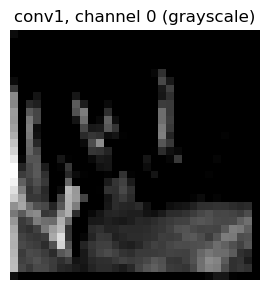

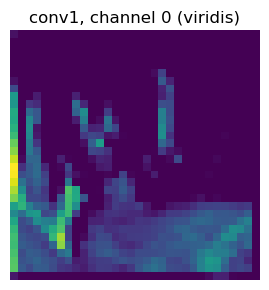

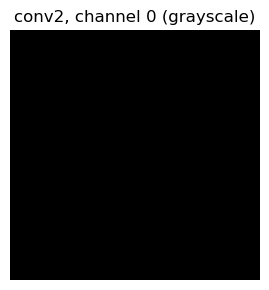

Saved files:
 - demo_artifacts\feature_maps\error_2_demo\conv1_channel0_gray.png
 - demo_artifacts\feature_maps\error_2_demo\conv1_channel0_viridis.png
 - demo_artifacts\feature_maps\error_2_demo\conv2_channel0_gray.png


In [4]:
class TinyFeatureNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 4, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(4, 6, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Linear(6, 10)

    def forward(self, x, return_features=False):
        f1 = self.relu(self.conv1(x))
        f2 = self.relu(self.conv2(f1))
        logits = self.head(self.pool(f2).flatten(1))
        if return_features:
            return logits, {"conv1": f1, "conv2": f2}
        return logits

feature_model = TinyFeatureNet().to(DEVICE)
image_0, label_0 = cifar_test[0]

with torch.no_grad():
    _, features = feature_model(image_0.unsqueeze(0).to(DEVICE), return_features=True)

conv1_map = features["conv1"][0, 0].cpu().numpy()
conv2_map = features["conv2"][0, 0].cpu().numpy()

save_dir_2 = FEATURE_MAP_DIR / "error_2_demo"
save_dir_2.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(3, 3))
plt.imshow(conv1_map, cmap="gray")
plt.title("conv1, channel 0 (grayscale)")
plt.axis("off")
plt.tight_layout()
plt.savefig(save_dir_2 / "conv1_channel0_gray.png", dpi=150)
plt.show()

plt.figure(figsize=(3, 3))
plt.imshow(conv1_map, cmap="viridis")
plt.title("conv1, channel 0 (viridis)")
plt.axis("off")
plt.tight_layout()
plt.savefig(save_dir_2 / "conv1_channel0_viridis.png", dpi=150)
plt.show()

plt.figure(figsize=(3, 3))
plt.imshow(conv2_map, cmap="gray")
plt.title("conv2, channel 0 (grayscale)")
plt.axis("off")
plt.tight_layout()
plt.savefig(save_dir_2 / "conv2_channel0_gray.png", dpi=150)
plt.show()

print("Saved files:")
for p in sorted(save_dir_2.glob("*.png")):
    print(" -", p.relative_to(PROJECT_ROOT))

### What to learn from Error 2

A correct minimal feature-map demo should make these points clear:

1. **Which layer** you used
2. **Which channel** you visualized
3. Whether you displayed it in **grayscale** or a **colormap**
4. Where you **saved** the result

That is much clearer than saying “we looked at the maps” without showing the actual extraction.

# Error 3 — Bad path handling: absolute paths, multiple roots, scattered outputs

## The mistake

Common bad patterns:

- hard-coded absolute paths such as `C:/Users/...`
- one dataset root in one cell and another root somewhere else
- saving outputs into random folders all over the machine

That makes the notebook hard to run on another computer.

## The fix

Use one small configuration block and keep everything relative to the project.

This is the exact style requested:

```python
SEED = 42
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / ".." / "Datasets"
ARTIFACTS_DIR = PROJECT_ROOT / "demo_artifacts"
RUNS_DIR = ARTIFACTS_DIR / "runs"
SPLITS_DIR = ARTIFACTS_DIR / "splits"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FEATURE_MAP_DIR = ARTIFACTS_DIR / "feature_maps"
```

Below we save **two CIFAR-10 images** into the artifact folder to show the idea.

In [5]:
path_demo_dir = FIGURES_DIR / "error_3_demo"
path_demo_dir.mkdir(parents=True, exist_ok=True)

for idx in [0, 1]:
    img, label = cifar_test[idx]
    out_name = f"cifar_example_{idx:02d}_{CIFAR_CLASSES[label]}.png"
    out_path = path_demo_dir / out_name
    save_image(img, out_path)
    print("Saved:", out_path.relative_to(PROJECT_ROOT))

print("\nOne dataset root:")
print("DATASET_ROOT =", DATASET_ROOT)

print("\nOne artifact tree:")
for folder in [RUNS_DIR, SPLITS_DIR, FIGURES_DIR, FEATURE_MAP_DIR]:
    print(" -", folder.relative_to(PROJECT_ROOT))

Saved: demo_artifacts\figures\error_3_demo\cifar_example_00_cat.png
Saved: demo_artifacts\figures\error_3_demo\cifar_example_01_ship.png

One dataset root:
DATASET_ROOT = c:\Users\jom_j\Documents\Master\Courses\IN4310\Coursework\Week_06\..\Datasets

One artifact tree:
 - demo_artifacts\runs
 - demo_artifacts\splits
 - demo_artifacts\figures
 - demo_artifacts\feature_maps


### What to learn from Error 3

The important idea is not “how to save one PNG”.  
The important idea is this:

- **one** dataset root,
- **one** artifact tree,
- **relative paths** inside the project.

That makes the work portable and much easier to grade.

# Error 5 + Error 9 — Saving scores but not verifying them after reload, and using `shuffle=True` for validation / test

## The mistake

A student saves:

- the model checkpoint,
- and a file of softmax scores,

but never checks whether:

1. the reloaded model produces the **same probabilities**, and
2. the samples are still in the **same order**.

The second part is exactly where `shuffle=True` becomes dangerous for validation and test loaders.

## The fix

For ordered score files:

- keep `shuffle=False` for validation / test,
- save **sample IDs together with probabilities**,
- reload the model,
- re-run inference,
- compare **IDs and probabilities**.

Below we use a tiny **two-layer MLP** with **random inputs only**.  
No training is needed for this demonstration.

In [7]:
class IndexedTensorDataset(Dataset):
    def __init__(self, X):
        self.X = X

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], f"sample_{idx:03d}"

class ScoreMLP(nn.Module):
    def __init__(self, in_dim=6, hidden_dim=12, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

seed_everything()
X_demo = torch.randn(12, 6)
score_dataset = IndexedTensorDataset(X_demo)

ordered_loader = DataLoader(score_dataset, batch_size=4, shuffle=False)
shuffled_loader = DataLoader(score_dataset, batch_size=4, shuffle=True)

score_model = ScoreMLP().to(DEVICE)
score_demo_dir = RUNS_DIR / "error_5_9_demo"
score_demo_dir.mkdir(parents=True, exist_ok=True)

def collect_scores(model, loader):
    model.eval()
    all_ids = []
    all_probs = []
    with torch.no_grad():
        for xb, ids in loader:
            xb = xb.to(DEVICE)
            probs = torch.softmax(model(xb), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_ids.extend(list(ids))
    return all_ids, np.concatenate(all_probs, axis=0)

# 1) Save checkpoint and ordered scores
ordered_ids, ordered_probs = collect_scores(score_model, ordered_loader)
checkpoint_path = score_demo_dir / "score_model.pt"
score_path = score_demo_dir / "ordered_scores.npz"

torch.save(score_model.state_dict(), checkpoint_path)
np.savez_compressed(score_path, sample_ids=np.array(ordered_ids), probs=ordered_probs)

# 2) Reload and compare with the SAME ordered loader
reloaded_model = ScoreMLP().to(DEVICE)
reloaded_model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))

reload_ids, reload_probs = collect_scores(reloaded_model, ordered_loader)

print("Ordered loader comparison:")
print("Same IDs  :", ordered_ids == reload_ids)
print("Same probs:", np.allclose(ordered_probs, reload_probs, atol=1e-7))

# 3) Now use shuffle=True and show why direct comparison becomes unsafe
shuffled_ids, shuffled_probs = collect_scores(reloaded_model, shuffled_loader)

print("\nShuffled loader comparison:")
print("Same IDs in same order :", ordered_ids == shuffled_ids)
print("Same raw probability array order:", np.allclose(ordered_probs, shuffled_probs, atol=1e-7))

comparison_df = pd.DataFrame({
    "ordered_ids": ordered_ids,
    "shuffled_ids": shuffled_ids[:len(ordered_ids)]
})
comparison_df.head(8)

Ordered loader comparison:
Same IDs  : True
Same probs: True

Shuffled loader comparison:
Same IDs in same order : False
Same raw probability array order: False


C:\Users\jom_j\AppData\Local\Temp\ipykernel_43376\3172047844.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reloaded_model.load_state_dict(torch.load(checkpoint_path, 

,ordered_ids,shuffled_ids
0,sample_000,sample_002
1,sample_001,sample_009
2,sample_002,sample_010
3,sample_003,sample_006
4,sample_004,sample_008
5,sample_005,sample_004
6,sample_006,sample_011
7,sample_007,sample_001


### What to learn from Error 5 + Error 9

The model itself may still be fine.  
The problem is often the **sample order**.

So the safe pattern is:

1. `shuffle=False` for validation / test
2. save `sample_id`
3. save probabilities
4. reload the model
5. re-run inference
6. compare both IDs and probabilities

Without that check, “saved scores” are much less trustworthy.

# Error 6 + Error 11 — Saving the last model instead of the best validation model, and forgetting `eval()` / `torch.no_grad()`

## The mistake

Two common issues often appear together:

### Mistake A: saving only the last checkpoint
A student trains for many epochs and saves only the final weights.
That is risky, because the best validation result may happen **earlier**.

### Mistake B: validating in training mode
A student forgets to switch from `train()` to `eval()` during validation / test.

That is especially bad when the model contains layers such as:
- **Dropout**
- **BatchNorm**

because they behave differently in training and evaluation.

## The fix

During each epoch:

- use `model.train()` only for the training pass,
- use `model.eval()` for validation / test,
- wrap validation / test in `torch.no_grad()`,
- and save a **best checkpoint** whenever the validation metric improves.

Below we use a tiny **dropout MLP**.
To make the “best is not last” effect visible in a very small demo, we deliberately corrupt the labels in the late training phase.
This exaggerates what can happen in real life with overfitting or unstable training.

In [8]:
def make_small_classification_problem(seed=SEED):
    g = torch.Generator().manual_seed(seed)
    x0 = torch.randn(120, 10, generator=g) * 0.8 + 0.0
    x1 = torch.randn(120, 10, generator=g) * 0.8 + 1.8
    X = torch.cat([x0, x1], dim=0)
    y = torch.cat([
        torch.zeros(120, dtype=torch.long),
        torch.ones(120, dtype=torch.long)
    ], dim=0)
    return X, y

X_small, y_small = make_small_classification_problem()

X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    X_small.numpy(), y_small.numpy(),
    test_size=0.5, random_state=SEED, stratify=y_small.numpy()
)
X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
    X_temp_s, y_temp_s,
    test_size=0.5, random_state=SEED, stratify=y_temp_s
)

train_loader_6 = DataLoader(
    TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                  torch.tensor(y_train_s, dtype=torch.long)),
    batch_size=32, shuffle=True
)
val_loader_6 = DataLoader(
    TensorDataset(torch.tensor(X_val_s, dtype=torch.float32),
                  torch.tensor(y_val_s, dtype=torch.long)),
    batch_size=64, shuffle=False
)
test_loader_6 = DataLoader(
    TensorDataset(torch.tensor(X_test_s, dtype=torch.float32),
                  torch.tensor(y_test_s, dtype=torch.long)),
    batch_size=64, shuffle=False
)

class DropoutMLP(nn.Module):
    def __init__(self, in_dim=10, hidden_dim=16, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)

def accuracy_from_loader(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = torch.argmax(model(xb), dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

def train_best_vs_last_demo(epochs=16, lr=1e-2):
    seed_everything()
    model = DropoutMLP().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    demo_dir = RUNS_DIR / "error_6_11_demo"
    demo_dir.mkdir(parents=True, exist_ok=True)

    best_val_acc = -1.0
    best_epoch = -1
    history = []

    best_path = demo_dir / "best_model.pt"
    last_path = demo_dir / "last_model.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader_6:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # In the late phase we intentionally damage training labels
            # so that the final epoch is not the best one.
            if epoch >= 11:
                yb = yb[torch.randperm(len(yb), device=yb.device)]

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        val_acc = accuracy_from_loader(model, val_loader_6)
        history.append({"epoch": epoch, "val_acc": val_acc})

        torch.save(model.state_dict(), last_path)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), best_path)

    history_df = pd.DataFrame(history)

    best_model = DropoutMLP().to(DEVICE)
    best_model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    last_model = DropoutMLP().to(DEVICE)
    last_model.load_state_dict(torch.load(last_path, map_location=DEVICE))

    summary = {
        "best_epoch": best_epoch,
        "best_val_acc": accuracy_from_loader(best_model, val_loader_6),
        "last_val_acc": accuracy_from_loader(last_model, val_loader_6),
        "best_test_acc": accuracy_from_loader(best_model, test_loader_6),
        "last_test_acc": accuracy_from_loader(last_model, test_loader_6),
        "best_path": str(best_path.relative_to(PROJECT_ROOT)),
        "last_path": str(last_path.relative_to(PROJECT_ROOT)),
    }
    return model, history_df, summary

model_6, history_6, summary_6 = train_best_vs_last_demo()
history_6

C:\Users\jom_j\AppData\Local\Temp\ipykernel_43376\2936271716.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_path, map_locat

,epoch,val_acc
0,1,0.733333
1,2,0.883333
2,3,0.900000
3,4,0.900000
4,5,0.933333
5,6,0.983333
6,7,0.983333
7,8,0.983333
8,9,0.983333
9,10,1.000000


Best epoch       : 10
Best val acc     : 1.0
Last val acc     : 0.5
Best test acc    : 1.0
Last test acc    : 0.5
Best checkpoint  : demo_artifacts\runs\error_6_11_demo\best_model.pt
Last checkpoint  : demo_artifacts\runs\error_6_11_demo\last_model.pt


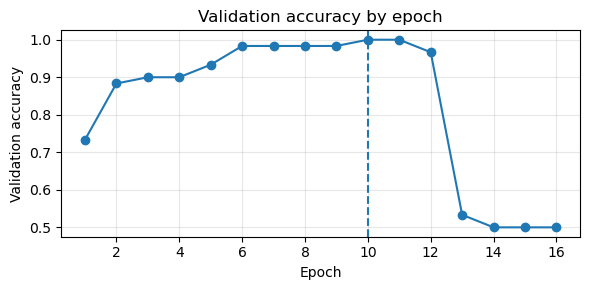

In [9]:
print("Best epoch       :", summary_6["best_epoch"])
print("Best val acc     :", round(summary_6["best_val_acc"], 4))
print("Last val acc     :", round(summary_6["last_val_acc"], 4))
print("Best test acc    :", round(summary_6["best_test_acc"], 4))
print("Last test acc    :", round(summary_6["last_test_acc"], 4))
print("Best checkpoint  :", summary_6["best_path"])
print("Last checkpoint  :", summary_6["last_path"])

plt.figure(figsize=(6, 3))
plt.plot(history_6["epoch"], history_6["val_acc"], marker="o")
plt.axvline(summary_6["best_epoch"], linestyle="--")
plt.title("Validation accuracy by epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Why forgetting `eval()` is bad

With dropout, the same input can produce different outputs in training mode.

That means validation / test results are unstable if you forget `model.eval()`.

In [10]:
demo_batch, _ = next(iter(val_loader_6))
demo_batch = demo_batch[:4].to(DEVICE)

dropout_model = DropoutMLP().to(DEVICE)

dropout_model.train()
train_out_1 = dropout_model(demo_batch)
train_out_2 = dropout_model(demo_batch)

dropout_model.eval()
eval_out_1 = dropout_model(demo_batch)
eval_out_2 = dropout_model(demo_batch)

print("Train mode: outputs equal?", torch.allclose(train_out_1, train_out_2))
print("Eval mode : outputs equal?", torch.allclose(eval_out_1, eval_out_2))

Train mode: outputs equal? False
Eval mode : outputs equal? True


## Why `torch.no_grad()` matters

`torch.no_grad()` does not change the prediction rule by itself.

Its job is to say:

- “I am only evaluating”
- “do not build a gradient graph”

That saves memory and avoids unnecessary gradient tracking.

In [11]:
dropout_model.eval()

out_without_no_grad = dropout_model(demo_batch)
with torch.no_grad():
    out_with_no_grad = dropout_model(demo_batch)

print("Output requires grad without no_grad():", out_without_no_grad.requires_grad)
print("Output requires grad with no_grad()   :", out_with_no_grad.requires_grad)

Output requires grad without no_grad(): True
Output requires grad with no_grad()   : False


### What to learn from Error 6 + Error 11

The safe validation / test pattern is:

```python
model.eval()
with torch.no_grad():
    ...
```

And the safe checkpoint pattern is:

- save `last_model.pt` if you want,
- but always also track and save **`best_model.pt`** based on the validation metric.

# Error 10 — Not showing a clean 3-run experiment setup

## The mistake

A student runs experiments by manually editing cells, commenting code in and out, and changing values by hand.

That makes it hard to answer a simple grading question:

- “Did you really run three experiments?”

## The fix

Show a clean list of runs.

You can do this with:
- a list of config dictionaries, or
- three explicit calls.

Below is a very small example of the **config-list approach**.
The point is only the structure.

In [12]:
class TinyMLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(8, 12), nn.ReLU(), nn.Linear(12, 3))
    def forward(self, x):
        return self.net(x)

class TinyMLPDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(8, 12), nn.ReLU(), nn.Dropout(0.3), nn.Linear(12, 3))
    def forward(self, x):
        return self.net(x)

class TinyMLPWide(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(8, 24), nn.ReLU(), nn.Linear(24, 3))
    def forward(self, x):
        return self.net(x)

RUN_CONFIGS = [
    {"run_name": "baseline", "model_class": TinyMLPBaseline, "lr": 1e-3},
    {"run_name": "dropout", "model_class": TinyMLPDropout, "lr": 1e-3},
    {"run_name": "wide", "model_class": TinyMLPWide, "lr": 5e-4},
]

for cfg in RUN_CONFIGS:
    print(f"Planned run -> {cfg['run_name']}: {cfg['model_class'].__name__}, lr={cfg['lr']}")
    # train_one_run(cfg)

Planned run -> baseline: TinyMLPBaseline, lr=0.001
Planned run -> dropout: TinyMLPDropout, lr=0.001
Planned run -> wide: TinyMLPWide, lr=0.0005


You could also show it explicitly like this:

```python
# 1. Baseline
train_competitor(BaselineModel, epochs=10, lr=0.001)

# 2. Your Model
train_competitor(MyCompetitorModel, epochs=10, lr=0.001)

# 3. Fusion Model
train_competitor(FusionModel, epochs=10, lr=0.001)
```

The grading idea is simple: **make the three runs visible and reproducible**.

# Error 12 — Feature map visualizations are not saved in a fixed, reproducible way

## The mistake

Students sometimes:

- pick random images,
- only show the maps inline,
- do not save files,
- or do not say which images were used.

That makes the visualization hard to reproduce.

## The fix

Use a fixed loader with `shuffle=False`, take the **first images in order**, and save:

- the input image,
- the chosen feature map,
- and the file paths.

Below we reuse the tiny convolutional model from Error 2 and save feature maps for the **first 3 images** from CIFAR-10 test.

In [13]:
fixed_loader_12 = DataLoader(cifar_test, batch_size=10, shuffle=False)
images_12, labels_12 = next(iter(fixed_loader_12))

save_dir_12 = FEATURE_MAP_DIR / "error_12_demo"
save_dir_12.mkdir(parents=True, exist_ok=True)

feature_model_12 = TinyFeatureNet().to(DEVICE)
feature_model_12.eval()

for i in range(3):
    img = images_12[i]
    label = labels_12[i]

    # Save the input image
    input_path = save_dir_12 / f"img_{i:02d}_input_{CIFAR_CLASSES[label]}.png"
    save_image(img, input_path)

    # Save one fixed feature map channel from conv1
    with torch.no_grad():
        _, feats = feature_model_12(img.unsqueeze(0).to(DEVICE), return_features=True)
    fmap = feats["conv1"][0, 0].cpu().numpy()

    fmap_path = save_dir_12 / f"img_{i:02d}_conv1_channel0_gray.png"
    plt.figure(figsize=(3, 3))
    plt.imshow(fmap, cmap="gray")
    plt.title(f"img {i:02d} | conv1 channel 0")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(fmap_path, dpi=150)
    plt.close()

print("Saved files for Error 12:")
for p in sorted(save_dir_12.glob("*.png")):
    print(" -", p.relative_to(PROJECT_ROOT))

Saved files for Error 12:
 - demo_artifacts\feature_maps\error_12_demo\img_00_conv1_channel0_gray.png
 - demo_artifacts\feature_maps\error_12_demo\img_00_input_cat.png
 - demo_artifacts\feature_maps\error_12_demo\img_01_conv1_channel0_gray.png
 - demo_artifacts\feature_maps\error_12_demo\img_01_input_ship.png
 - demo_artifacts\feature_maps\error_12_demo\img_02_conv1_channel0_gray.png
 - demo_artifacts\feature_maps\error_12_demo\img_02_input_ship.png


### What to learn from Error 12

A good feature-map submission is not just “here is a plot”.

It should say:

- which images were used,
- which layer was used,
- which channel was used,
- and where the saved files are.

Using the **first items from a fixed loader** is a simple way to make the choice reproducible.

# Final takeaway

This notebook is deliberately simple, but each demo shows the **main correction pattern**:

- **Error 1:** report per-class metrics, not just one overall number
- **Error 2:** extract real feature maps and save them
- **Error 3:** keep paths relative and organized
- **Error 5 + 9:** save IDs, use `shuffle=False`, reload and verify scores
- **Error 6 + 11:** save the best validation checkpoint and evaluate with `eval()` + `torch.no_grad()`
- **Error 10:** show a clean 3-run setup
- **Error 12:** save feature maps for a fixed, reproducible set of images

That is the core logic the assignment wants students to understand.